In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
rcParams['figure.figsize'] = [12, 8]
rcParams['font.size'] = 10
sns.set_palette("husl")

def preprocess_data(df):
    """Preprocess the dataframe for visualization"""
    # Create a copy to avoid modifying the original
    df_vis = df.copy()
    
    # Clean up locus values
    if 'locus' in df_vis.columns:
        df_vis['locus_clean'] = df_vis['locus'].astype(str).str.upper().str.strip()
    
    # Extract gene family from best_v_call
    if 'best_v_call' in df_vis.columns:
        def extract_v_family(x):
            if pd.isna(x):
                return 'Unknown'
            try:
                if isinstance(x, str):
                    x_clean = x.split('*')[0]
                    parts = x_clean.split('-')
                    if len(parts) >= 2:
                        family_part = parts[0]
                        if family_part.startswith(('IGHV', 'IGKV', 'IGLV', 'TRAV', 'TRBV', 'TRDV', 'TRGV')):
                            return family_part
                        else:
                            return x_clean
                    else:
                        return x_clean
                return 'Unknown'
            except:
                return 'Unknown'
        
        df_vis['v_gene_family'] = df_vis['best_v_call'].apply(extract_v_family)
        
        # Extract gene name without allele (e.g., IGHV3-64*03 -> IGHV3-64)
        def extract_v_gene_name(x):
            if pd.isna(x):
                return 'Unknown'
            try:
                if isinstance(x, str):
                    # Split by asterisk and take first part
                    gene_name = x.split('*')[0]
                    # Remove trailing letters after numbers (like D in IGHV3-64D)
                    # Keep only IGHV3-64 part
                    parts = gene_name.split('-')
                    if len(parts) >= 2:
                        # Keep numbers only in the second part
                        numbers = ''.join(filter(str.isdigit, parts[1]))
                        if numbers:
                            return f"{parts[0]}-{numbers}"
                        else:
                            return gene_name
                    return gene_name
                return 'Unknown'
            except:
                return 'Unknown'
        
        df_vis['v_gene_name'] = df_vis['best_v_call'].apply(extract_v_gene_name)
    
    # Create pgen_log column if pgen exists
    if 'pgen' in df_vis.columns:
        try:
            pgen_series = pd.to_numeric(df_vis['pgen'], errors='coerce')
            # Replace zeros and negative values with small positive value
            pgen_series = pgen_series.replace(0, 1e-300)
            pgen_series[pgen_series <= 0] = 1e-300
            df_vis['pgen_log'] = -np.log10(pgen_series)
        except Exception as e:
            print(f"Error processing pgen column: {e}")
            df_vis['pgen_log'] = np.nan
    
    return df_vis

def plot_locus_frequencies_percentage(df, top_n=5):
    """Plot locus frequencies as percentages"""
    if 'locus_clean' not in df.columns:
        print("'locus_clean' column not found. Skipping locus plots.")
        return
    
    group_cols = ['condition', 'tissue_type']
    available_cols = [col for col in group_cols if col in df.columns]
    
    if not available_cols:
        print("No grouping columns found. Skipping locus plots.")
        return
    
    fig, axes = plt.subplots(1, len(available_cols), figsize=(5*len(available_cols), 6))
    if len(available_cols) == 1:
        axes = [axes]
    
    for idx, group_col in enumerate(available_cols):
        ax = axes[idx]
        
        try:
            # Calculate percentages
            locus_pct = pd.crosstab(df[group_col], df['locus_clean'], normalize='index') * 100
            
            # Keep only top N loci for clarity
            top_loci = df['locus_clean'].value_counts().head(top_n).index
            locus_pct = locus_pct[top_loci]
            
            # Plot stacked bar
            locus_pct.plot(kind='bar', stacked=True, ax=ax)
            ax.set_title(f'Locus Distribution by {group_col.replace("_", " ").title()} (%)')
            ax.set_xlabel(group_col.replace("_", " ").title())
            ax.set_ylabel('Percentage (%)')
            ax.legend(title='Locus', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.tick_params(axis='x', rotation=45)
            ax.set_ylim([0, 100])
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)[:50]}", 
                   ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

def plot_v_gene_frequencies_percentage(df, level='family', top_n=10):
    """Plot V gene frequencies as percentages"""
    
    # Determine which column to use
    if level == 'family':
        gene_col = 'v_gene_family'
    elif level == 'gene':
        gene_col = 'v_gene_name'
    else:
        gene_col = 'best_v_call'
    
    if gene_col not in df.columns:
        print(f"Column '{gene_col}' not found. Skipping V gene plots.")
        return
    
    # Get top genes overall
    top_genes = df[gene_col].value_counts().head(top_n).index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    axes = axes.flatten()
    
    # Plot 1: Overall top V genes (percentage)
    ax = axes[0]
    try:
        total_sequences = len(df)
        top_counts = df[gene_col].value_counts().head(10)
        top_pct = (top_counts / total_sequences * 100).sort_values(ascending=False)
        
        bars = ax.bar(range(len(top_pct)), top_pct.values, color='steelblue')
        ax.set_title(f'Top 10 V-gene {level.title()}s Overall (%)')
        ax.set_xlabel(f'V-gene {level.title()}')
        ax.set_ylabel('Percentage (%)')
        ax.set_xticks(range(len(top_pct)))
        ax.set_xticklabels(top_pct.index, rotation=45, ha='right')
        
        # Add percentage labels on bars
        for bar, pct in zip(bars, top_pct.values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:50]}", 
               ha='center', va='center', transform=ax.transAxes)
    
    # Plot 2: By condition (percentage)
    ax = axes[1]
    if 'condition' in df.columns:
        try:
            # Calculate percentages for each condition
            condition_pct_data = []
            for condition in df['condition'].unique():
                condition_df = df[df['condition'] == condition]
                condition_total = len(condition_df)
                for gene in top_genes:
                    count = len(condition_df[condition_df[gene_col] == gene])
                    pct = (count / condition_total * 100) if condition_total > 0 else 0
                    condition_pct_data.append({
                        'condition': condition,
                        'gene': gene,
                        'percentage': pct
                    })
            
            condition_pct_df = pd.DataFrame(condition_pct_data)
            
            # Pivot for plotting
            pivot_df = condition_pct_df.pivot(index='condition', columns='gene', values='percentage')
            pivot_df = pivot_df.fillna(0)
            
            # Plot
            pivot_df.plot(kind='bar', ax=ax, width=0.8)
            ax.set_title(f'V-gene {level.title()} Distribution by Condition (%)')
            ax.set_xlabel('Condition')
            ax.set_ylabel('Percentage (%)')
            ax.legend(title=f'V-gene {level}', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.tick_params(axis='x', rotation=45)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)[:50]}", 
                   ha='center', va='center', transform=ax.transAxes)
    
    # Plot 3: By tissue type (percentage)
    ax = axes[2]
    if 'tissue_type' in df.columns:
        try:
            # Calculate percentages for each tissue type
            tissue_pct_data = []
            for tissue in df['tissue_type'].unique():
                tissue_df = df[df['tissue_type'] == tissue]
                tissue_total = len(tissue_df)
                for gene in top_genes:
                    count = len(tissue_df[tissue_df[gene_col] == gene])
                    pct = (count / tissue_total * 100) if tissue_total > 0 else 0
                    tissue_pct_data.append({
                        'tissue_type': tissue,
                        'gene': gene,
                        'percentage': pct
                    })
            
            tissue_pct_df = pd.DataFrame(tissue_pct_data)
            
            # Pivot for plotting
            pivot_df = tissue_pct_df.pivot(index='tissue_type', columns='gene', values='percentage')
            pivot_df = pivot_df.fillna(0)
            
            # Plot
            pivot_df.plot(kind='bar', ax=ax, width=0.8)
            ax.set_title(f'V-gene {level.title()} Distribution by Tissue Type (%)')
            ax.set_xlabel('Tissue Type')
            ax.set_ylabel('Percentage (%)')
            ax.legend(title=f'V-gene {level}', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.tick_params(axis='x', rotation=45)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)[:50]}", 
                   ha='center', va='center', transform=ax.transAxes)
    
    # Plot 4: Heatmap of top gene percentage across conditions and tissues
    ax = axes[3]
    if 'condition' in df.columns and 'tissue_type' in df.columns:
        try:
            # Get the top gene
            top_gene = top_genes[0] if top_genes else None
            
            if top_gene:
                # Create cross-tabulation with percentages
                heatmap_data = pd.crosstab(
                    df['condition'], 
                    df['tissue_type'], 
                    values=(df[gene_col] == top_gene).astype(float),
                    aggfunc='mean',
                    normalize='index'
                ).fillna(0) * 100
                
                # Plot heatmap
                sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
                           cbar_kws={'label': 'Percentage (%)'}, ax=ax)
                ax.set_title(f'Percentage of {top_gene} by Condition and Tissue Type')
                ax.set_xlabel('Tissue Type')
                ax.set_ylabel('Condition')
            else:
                ax.text(0.5, 0.5, "No genes found", 
                       ha='center', va='center', transform=ax.transAxes)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)[:50]}", 
                   ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

def plot_pgen_distributions_filtered(df, pgen_cutoff=20):
    """Plot pgen distributions with cutoff filter"""
    
    if 'pgen_log' not in df.columns:
        print("'pgen_log' column not found. Skipping pgen plots.")
        return
    
    # Filter extreme values (pgen_log > 20)
    df_filtered = df[df['pgen_log'] <= pgen_cutoff].copy()
    removed_count = len(df) - len(df_filtered)
    
    print(f"Filtered out {removed_count} sequences with pgen_log > {pgen_cutoff}")
    print(f"Remaining sequences: {len(df_filtered)}")
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    # Plot 1: Distribution of filtered pgen_log
    ax = axes[0]
    sns.histplot(df_filtered['pgen_log'], kde=True, ax=ax, bins=50)
    ax.set_title(f'Distribution of pgen_log (filtered ≤ {pgen_cutoff})')
    ax.set_xlabel('-log10(pgen)')
    ax.set_ylabel('Frequency')
    ax.axvline(x=df_filtered['pgen_log'].median(), color='r', linestyle='--', 
               label=f'Median: {df_filtered["pgen_log"].median():.2f}')
    ax.legend()
    
    # Plot 2: Boxplot by condition
    ax = axes[1]
    if 'condition' in df_filtered.columns:
        sns.boxplot(x='condition', y='pgen_log', data=df_filtered, ax=ax)
        ax.set_title(f'pgen_log by Condition (filtered ≤ {pgen_cutoff})')
        ax.set_xlabel('Condition')
        ax.set_ylabel('-log10(pgen)')
        ax.tick_params(axis='x', rotation=45)
    
    # Plot 3: Boxplot by tissue type
    ax = axes[2]
    if 'tissue_type' in df_filtered.columns:
        sns.boxplot(x='tissue_type', y='pgen_log', data=df_filtered, ax=ax)
        ax.set_title(f'pgen_log by Tissue Type (filtered ≤ {pgen_cutoff})')
        ax.set_xlabel('Tissue Type')
        ax.set_ylabel('-log10(pgen)')
        ax.tick_params(axis='x', rotation=45)
    
    # Plot 4: Violin plot by condition and tissue
    ax = axes[3]
    if 'condition' in df_filtered.columns and 'tissue_type' in df_filtered.columns:
        # Combine for better visualization
        df_filtered['condition_tissue'] = df_filtered['condition'] + '_' + df_filtered['tissue_type']
        # Take top 8 combinations for clarity
        top_combos = df_filtered['condition_tissue'].value_counts().head(8).index
        df_top = df_filtered[df_filtered['condition_tissue'].isin(top_combos)]
        
        if not df_top.empty:
            sns.violinplot(x='condition_tissue', y='pgen_log', data=df_top, ax=ax)
            ax.set_title(f'pgen_log by Condition × Tissue (filtered ≤ {pgen_cutoff})')
            ax.set_xlabel('Condition × Tissue')
            ax.set_ylabel('-log10(pgen)')
            ax.tick_params(axis='x', rotation=45)
    
    # Plot 5: Scatter plot of pgen_log vs sequence count per sample
    ax = axes[4]
    if 'sample' in df_filtered.columns:
        sample_stats = df_filtered.groupby('sample').agg({
            'pgen_log': 'mean',
            'sequence_id': 'count'
        }).reset_index()
        sample_stats.columns = ['sample', 'mean_pgen_log', 'sequence_count']
        
        if 'condition' in df_filtered.columns:
            # Add condition info
            conditions = df_filtered[['sample', 'condition']].drop_duplicates()
            sample_stats = pd.merge(sample_stats, conditions, on='sample')
            
            # Plot scatter with color by condition
            scatter = ax.scatter(sample_stats['sequence_count'], 
                                sample_stats['mean_pgen_log'],
                                c=pd.factorize(sample_stats['condition'])[0],
                                alpha=0.6, s=50)
            ax.set_title(f'Mean pgen_log vs Sequence Count per Sample')
            ax.set_xlabel('Sequence Count per Sample')
            ax.set_ylabel('Mean pgen_log')
            
            # Add legend for conditions
            unique_conditions = sample_stats['condition'].unique()
            handles = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=plt.cm.tab10(i), markersize=10)
                      for i in range(len(unique_conditions))]
            ax.legend(handles, unique_conditions, title='Condition')
        else:
            ax.scatter(sample_stats['sequence_count'], 
                      sample_stats['mean_pgen_log'], alpha=0.6, s=50)
            ax.set_title(f'Mean pgen_log vs Sequence Count per Sample')
            ax.set_xlabel('Sequence Count per Sample')
            ax.set_ylabel('Mean pgen_log')
    
    # Plot 6: Cumulative distribution
    ax = axes[5]
    if len(df_filtered) > 0:
        sorted_pgen = np.sort(df_filtered['pgen_log'].dropna())
        y = np.arange(1, len(sorted_pgen) + 1) / len(sorted_pgen) * 100
        
        ax.plot(sorted_pgen, y, linewidth=2)
        ax.set_title('Cumulative Distribution of pgen_log')
        ax.set_xlabel('-log10(pgen)')
        ax.set_ylabel('Cumulative Percentage (%)')
        ax.grid(True, alpha=0.3)
        
        # Add median line
        median_val = np.median(sorted_pgen)
        ax.axvline(x=median_val, color='r', linestyle='--', 
                  label=f'Median: {median_val:.2f}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return df_filtered

def get_groups_with_comparisons(df, group_by='patient'):
    """
    Identify groups (patients or conditions) that have tissue types for comparison.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    group_by : str
        'patient' or 'condition'
        
    Returns:
    --------
    list
        List of groups that have tissue types for comparison
    """
    if group_by not in ['patient', 'condition']:
        raise ValueError("group_by must be 'patient' or 'condition'")
    
    group_column = 'patient_id' if group_by == 'patient' else 'condition'
    
    if group_column not in df.columns:
        print(f"'{group_column}' column not found.")
        return []
    
    groups_with_comparisons = []
    
    for group in df[group_column].unique():
        group_df = df[df[group_column] == group]
        tissue_types = set(group_df['tissue_type'].unique())
        
        # Skip CTRL condition if it only has 'healthy'
        if group_by == 'condition' and group == 'CTRL':
            # For CTRL, we only expect 'healthy', skip comparison
            continue
        
        # For PSO and AD patients/conditions
        if 'lesional' in tissue_types and 'non-lesional' in tissue_types:
            groups_with_comparisons.append(group)
        elif 'lesional' in tissue_types and 'healthy' in tissue_types:
            groups_with_comparisons.append(group)
        elif 'non-lesional' in tissue_types and 'healthy' in tissue_types:
            groups_with_comparisons.append(group)
    
    print(f"Found {len(groups_with_comparisons)} {group_by}s with tissue types for comparison")
    return groups_with_comparisons

def plot_group_comparisons(df, group_by='patient', pgen_cutoff=20):
    """
    Compare tissue types for each group (patient or condition).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    group_by : str
        'patient' or 'condition'
    pgen_cutoff : int
        Cutoff for pgen_log values
    """
    
    required_cols = ['tissue_type']
    group_column = 'patient_id' if group_by == 'patient' else 'condition'
    required_cols.append(group_column)
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Missing required columns for {group_by} comparisons: {missing_cols}")
        return []
    
    # Get groups with comparisons
    groups_with_comparisons = get_groups_with_comparisons(df, group_by)
    
    if not groups_with_comparisons:
        print(f"No {group_by}s with tissue types for comparison found.")
        return []
    
    # Limit to top 12 groups for visualization clarity
    groups_to_plot = groups_with_comparisons[:12]
    
    # Create subplots for pgen comparison
    n_groups = len(groups_to_plot)
    n_cols = min(4, n_groups)
    n_rows = (n_groups + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes array for easier indexing
    axes_flat = axes.flatten()
    
    for idx, group in enumerate(groups_to_plot):
        ax = axes_flat[idx]
        
        # Get group data
        group_df = df[df[group_column] == group].copy()
        
        # Filter pgen if available
        if 'pgen_log' in group_df.columns:
            group_df = group_df[group_df['pgen_log'] <= pgen_cutoff]
        
        # Get available tissue types
        tissue_types = group_df['tissue_type'].unique()
        
        # Skip if only one tissue type
        if len(tissue_types) < 2:
            ax.text(0.5, 0.5, 'Only one tissue type', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{group_by.title()} {group}')
            continue
        
        # Create boxplot comparing tissue types
        tissue_data = []
        tissue_labels = []
        
        for tissue in tissue_types:
            if tissue in ['lesional', 'non-lesional', 'healthy']:
                tissue_data.append(group_df[group_df['tissue_type'] == tissue]['pgen_log'].dropna())
                tissue_labels.append(tissue)
        
        if len(tissue_data) < 2:
            ax.text(0.5, 0.5, 'Insufficient tissue types', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{group_by.title()} {group}')
            continue
        
        positions = range(1, len(tissue_data) + 1)
        
        bp = ax.boxplot(tissue_data, positions=positions, widths=0.6, 
                       patch_artist=True, showfliers=False)
        
        # Color the boxes
        colors = ['lightcoral', 'lightblue', 'lightgreen']
        for patch, color in zip(bp['boxes'], colors[:len(tissue_data)]):
            patch.set_facecolor(color)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(tissue_labels)
        
        # Set title with sample sizes
        title = f'{group_by.title()} {group}\n'
        for tissue, data in zip(tissue_labels, tissue_data):
            title += f'{tissue}:{len(data)} '
        ax.set_title(title.strip())
        
        ax.set_ylabel('-log10(pgen)')
        
        # Add mean lines
        for i, data in enumerate(tissue_data):
            if len(data) > 0:
                ax.axhline(y=data.mean(), color=colors[i], linestyle='--', 
                          alpha=0.7, linewidth=1)
    
    # Hide unused subplots
    for idx in range(len(groups_to_plot), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle(f'pgen Distribution by Tissue Type for Each {group_by.title()}', 
                 y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return groups_to_plot

def plot_v_gene_comparison_by_group(df, groups_to_plot, group_by='patient', level='gene', top_n=5):
    """
    Compare V gene frequencies between tissue types for each group.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    groups_to_plot : list
        List of groups to plot
    group_by : str
        'patient' or 'condition'
    level : str
        'family' or 'gene'
    top_n : int
        Number of top genes to display
    """
    
    group_column = 'patient_id' if group_by == 'patient' else 'condition'
    
    if level == 'family':
        gene_col = 'v_gene_family'
    elif level == 'gene':
        gene_col = 'v_gene_name'
    else:
        gene_col = 'best_v_call'
    
    if gene_col not in df.columns:
        print(f"Column '{gene_col}' not found. Skipping V gene comparisons.")
        return
    
    # Create subplots
    n_groups = len(groups_to_plot)
    n_cols = min(3, n_groups)
    n_rows = (n_groups + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes_flat = axes.flatten()
    
    for idx, group in enumerate(groups_to_plot):
        ax = axes_flat[idx]
        
        # Get group data
        group_df = df[df[group_column] == group].copy()
        
        # Get tissue types
        tissue_types = group_df['tissue_type'].unique()
        
        if len(tissue_types) < 2:
            ax.text(0.5, 0.5, 'Only one tissue type', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{group_by.title()} {group}')
            continue
        
        # Get top genes across all tissue types
        all_genes = group_df[gene_col].value_counts()
        top_genes = all_genes.head(top_n).index.tolist()
        
        # Prepare data for plotting
        tissue_data = {}
        sample_sizes = {}
        
        for tissue in tissue_types:
            if tissue in ['lesional', 'non-lesional', 'healthy']:
                tissue_df = group_df[group_df['tissue_type'] == tissue]
                sample_sizes[tissue] = len(tissue_df)
                
                if len(tissue_df) > 0:
                    tissue_counts = tissue_df[gene_col].value_counts().reindex(top_genes, fill_value=0)
                    tissue_pct = tissue_counts / len(tissue_df) * 100
                    tissue_data[tissue] = tissue_pct
        
        if len(tissue_data) < 2:
            ax.text(0.5, 0.5, 'Insufficient data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{group_by.title()} {group}')
            continue
        
        # Create grouped bar plot
        x = np.arange(len(top_genes))
        width = 0.8 / len(tissue_data)
        
        colors = ['lightcoral', 'lightblue', 'lightgreen']
        edge_colors = ['darkred', 'darkblue', 'darkgreen']
        
        for i, (tissue, pct_data) in enumerate(tissue_data.items()):
            offset = (i - (len(tissue_data)-1)/2) * width
            bars = ax.bar(x + offset, pct_data.values, width, 
                         label=tissue, color=colors[i], 
                         edgecolor=edge_colors[i], linewidth=1)
            
            # Add value labels on top of bars
            for bar, value in zip(bars, pct_data.values):
                if value > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., value + 0.5,
                           f'{value:.1f}%', ha='center', va='bottom', fontsize=7)
        
        ax.set_xlabel(f'Top {level.title()} V-genes')
        ax.set_ylabel('Percentage (%)')
        
        # Create title with sample sizes
        title = f'{group_by.title()} {group}\n'
        for tissue, size in sample_sizes.items():
            if tissue in tissue_data:
                title += f'{tissue}:{size} '
        ax.set_title(title.strip())
        
        ax.set_xticks(x)
        ax.set_xticklabels(top_genes, rotation=45, ha='right')
        ax.legend()
        
        # Set y limit
        max_pct = max([max(pct.values) for pct in tissue_data.values()])
        ax.set_ylim([0, max_pct * 1.2])
    
    # Hide unused subplots
    for idx in range(len(groups_to_plot), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle(f'Top {top_n} V-gene {level.title()}s by Tissue Type for Each {group_by.title()} (%)', 
                y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def create_group_comparison_heatmaps(df, groups_to_plot, group_by='patient', level='gene', top_n=10):
    """
    Create heatmaps comparing V gene usage between groups and tissue types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    groups_to_plot : list
        List of groups to plot
    group_by : str
        'patient' or 'condition'
    level : str
        'family' or 'gene'
    top_n : int
        Number of top genes to display
    """
    
    group_column = 'patient_id' if group_by == 'patient' else 'condition'
    
    if level == 'family':
        gene_col = 'v_gene_family'
    elif level == 'gene':
        gene_col = 'v_gene_name'
    else:
        gene_col = 'best_v_call'
    
    if gene_col not in df.columns:
        print(f"Column '{gene_col}' not found. Skipping heatmaps.")
        return
    
    # Prepare data for different tissue types
    tissue_types = ['lesional', 'non-lesional', 'healthy']
    available_tissues = [t for t in tissue_types if t in df['tissue_type'].unique()]
    
    if not available_tissues:
        print("No tissue types found for heatmaps.")
        return
    
    # Create subplots for each tissue type
    n_tissues = len(available_tissues)
    fig, axes = plt.subplots(1, n_tissues, figsize=(6*n_tissues, 8))
    if n_tissues == 1:
        axes = [axes]
    
    for idx, tissue in enumerate(available_tissues):
        ax = axes[idx]
        
        # Prepare data for this tissue type
        tissue_data = []
        
        for group in groups_to_plot:
            group_tissue_df = df[(df[group_column] == group) & (df['tissue_type'] == tissue)]
            
            if len(group_tissue_df) > 0:
                # Get top genes for this group and tissue
                gene_counts = group_tissue_df[gene_col].value_counts(normalize=True).head(top_n) * 100
                
                for gene, pct in gene_counts.items():
                    tissue_data.append({
                        'group': group,
                        'gene': gene,
                        'percentage': pct
                    })
        
        if tissue_data:
            tissue_df = pd.DataFrame(tissue_data)
            
            # Pivot for heatmap
            try:
                pivot_df = tissue_df.pivot(index='group', columns='gene', values='percentage').fillna(0)
                
                # Sort columns by total percentage
                column_sums = pivot_df.sum()
                pivot_df = pivot_df[column_sums.sort_values(ascending=False).index]
                
                # Create heatmap
                cmap = 'Reds' if tissue == 'lesional' else 'Blues' if tissue == 'non-lesional' else 'Greens'
                sns.heatmap(pivot_df, cmap=cmap, annot=True, fmt='.1f', 
                           linewidths=0.5, ax=ax, cbar_kws={'label': 'Percentage (%)'})
                ax.set_title(f'{tissue.title()} Samples')
                ax.set_xlabel(f'V-gene {level.title()}')
                ax.set_ylabel(f'{group_by.title()}')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error creating heatmap\n{str(e)[:50]}', 
                       ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, f'No data for {tissue} tissue', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{tissue.title()} Samples')
    
    plt.suptitle(f'Top {top_n} V-gene {level.title()}s by {group_by.title()} and Tissue Type (%)', 
                 y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def main_visualization_pipeline(df_path=None, df=None, pgen_cutoff=20, group_by='patient'):
    """
    Main function to run all visualizations for grouped data.
    
    Parameters:
    -----------
    df_path : str, optional
        Path to CSV file
    df : pandas.DataFrame, optional
        Input dataframe
    pgen_cutoff : int
        Cutoff for pgen_log values
    group_by : str
        'patient' or 'condition' - determines grouping level for comparisons
    """
    
    # Load data if path is provided
    if df_path and df is None:
        print(f"Loading data from {df_path}")
        try:
            df = pd.read_csv(df_path)
        except Exception as e:
            print(f"Error loading data: {e}")
            return
    elif df is None:
        print("Please provide either a dataframe or a file path")
        return
    
    print(f"Data shape: {df.shape}")
    print(f"Grouping by: {group_by}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Preprocess data
    print("\nPreprocessing data...")
    df_processed = preprocess_data(df)
    
    # Check for required columns
    print("\nChecking column availability:")
    required_cols = ['condition', 'patient_id', 'tissue_type', 'best_v_call']
    for col in required_cols:
        if col in df_processed.columns:
            print(f"  ✓ {col}")
        else:
            print(f"  ✗ {col} (not found)")
    
    # 1. Plot locus frequencies (percentage)
    print("\n1. Plotting locus frequencies (percentage)...")
    plot_locus_frequencies_percentage(df_processed)
    
    # 2. Plot V gene frequencies (percentage)
    print("\n2. Plotting V gene frequencies (percentage)...")
    plot_v_gene_frequencies_percentage(df_processed, level='family')
    plot_v_gene_frequencies_percentage(df_processed, level='gene')
    
    # 3. Plot pgen distributions with cutoff
    print("\n3. Plotting pgen distributions (with cutoff)...")
    df_filtered = plot_pgen_distributions_filtered(df_processed, pgen_cutoff)
    
    # 4. Group-level comparisons
    print(f"\n4. {group_by.title()}-level comparisons...")
    groups_with_comparisons = plot_group_comparisons(df_filtered, group_by, pgen_cutoff)
    
    if groups_with_comparisons:
        # 5. V gene comparisons by group
        print(f"\n5. V gene comparisons by {group_by} (family level)...")
        plot_v_gene_comparison_by_group(df_filtered, groups_with_comparisons[:8], 
                                       group_by, level='family', top_n=5)
        
        print(f"\n6. V gene comparisons by {group_by} (gene level)...")
        plot_v_gene_comparison_by_group(df_filtered, groups_with_comparisons[:8], 
                                       group_by, level='gene', top_n=5)
        
        # 7. Heatmaps
        print(f"\n7. Creating comparison heatmaps for {group_by}s...")
        create_group_comparison_heatmaps(df_filtered, groups_with_comparisons[:12], 
                                        group_by, level='gene', top_n=10)
    
    print(f"\n{group_by.title()}-level visualization pipeline completed!")

# Example usage:
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')
    
    # For patient-level analysis:
    # main_visualization_pipeline(df=df, group_by='patient')
    
    # For condition-level analysis:
    # main_visualization_pipeline(df=df, group_by='condition')
    
    pass

In [4]:
df = pd.read_csv('data.csv')

Data shape: (16172, 125)
Grouping by: patient
Columns: ['duplicate_count', 'sequence_id', 'sequence', 'sequence_aa', 'locus', 'stop_codon', 'vj_in_frame', 'v_frameshift', 'productive', 'rev_comp', 'complete_vdj', 'd_frame', 'v_call', 'd_call', 'j_call', 'c_call', 'sequence_alignment', 'germline_alignment', 'sequence_alignment_aa', 'germline_alignment_aa', 'v_alignment_start', 'v_alignment_end', 'd_alignment_start', 'd_alignment_end', 'j_alignment_start', 'j_alignment_end', 'c_alignment_start', 'c_alignment_end', 'v_sequence_alignment', 'v_sequence_alignment_aa', 'v_germline_alignment', 'v_germline_alignment_aa', 'd_sequence_alignment', 'd_sequence_alignment_aa', 'd_germline_alignment', 'd_germline_alignment_aa', 'j_sequence_alignment', 'j_sequence_alignment_aa', 'j_germline_alignment', 'j_germline_alignment_aa', 'c_sequence_alignment', 'c_sequence_alignment_aa', 'c_germline_alignment', 'c_germline_alignment_aa', 'fwr1', 'fwr1_aa', 'cdr1', 'cdr1_aa', 'fwr2', 'fwr2_aa', 'cdr2', 'cdr2_aa'

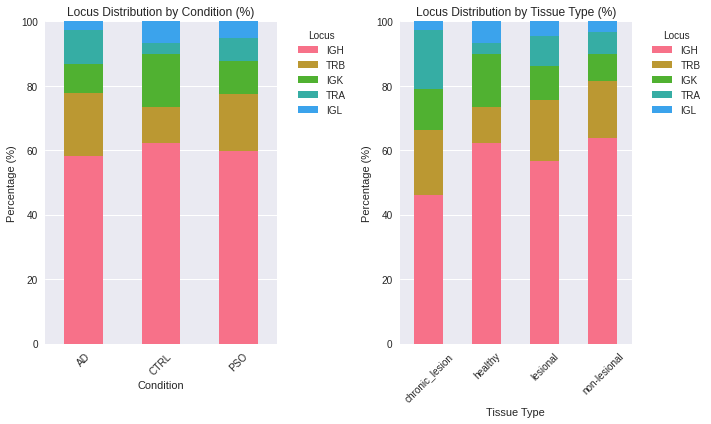


2. Plotting V gene frequencies (percentage)...


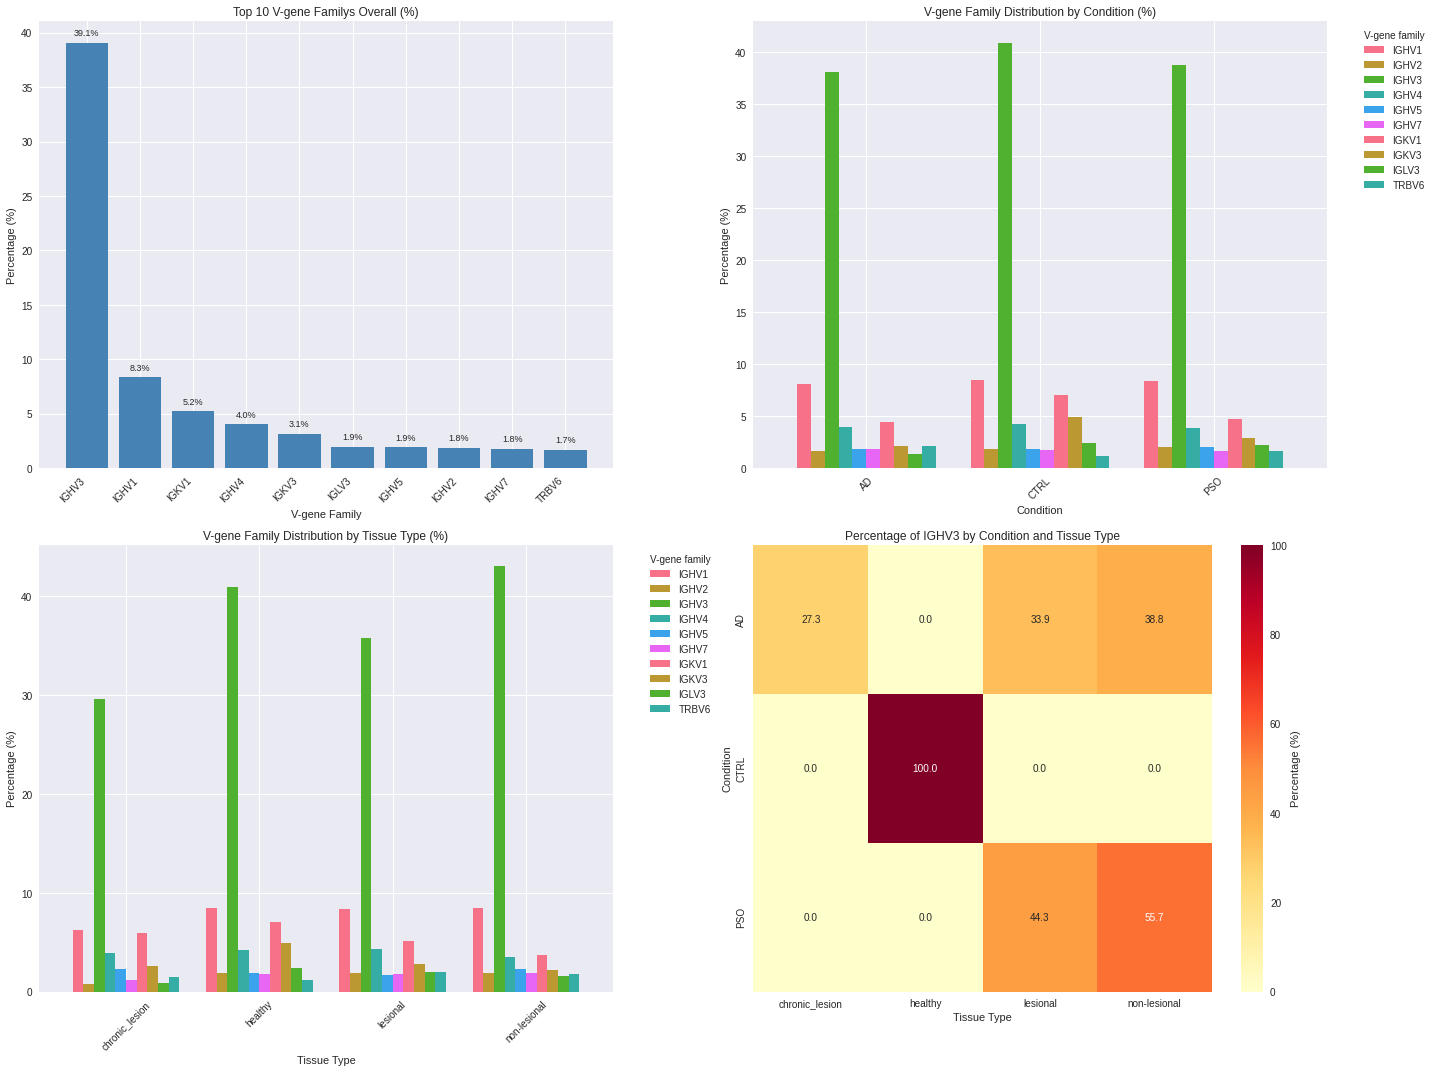

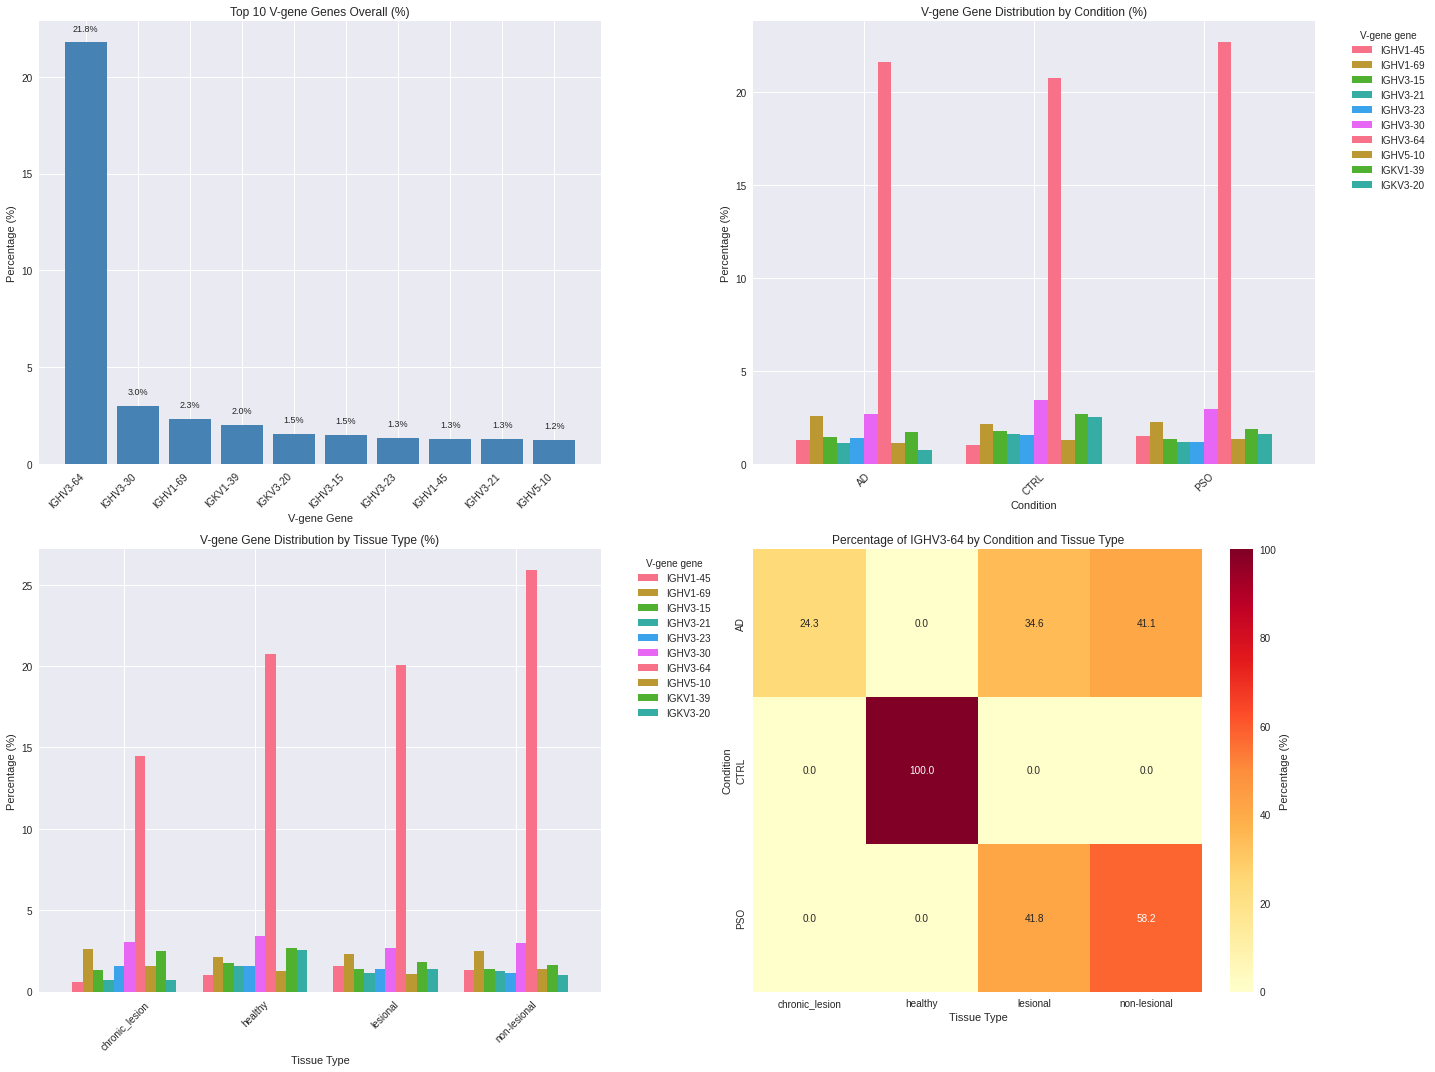


3. Plotting pgen distributions (with cutoff)...
Filtered out 6600 sequences with pgen_log > 20
Remaining sequences: 9572


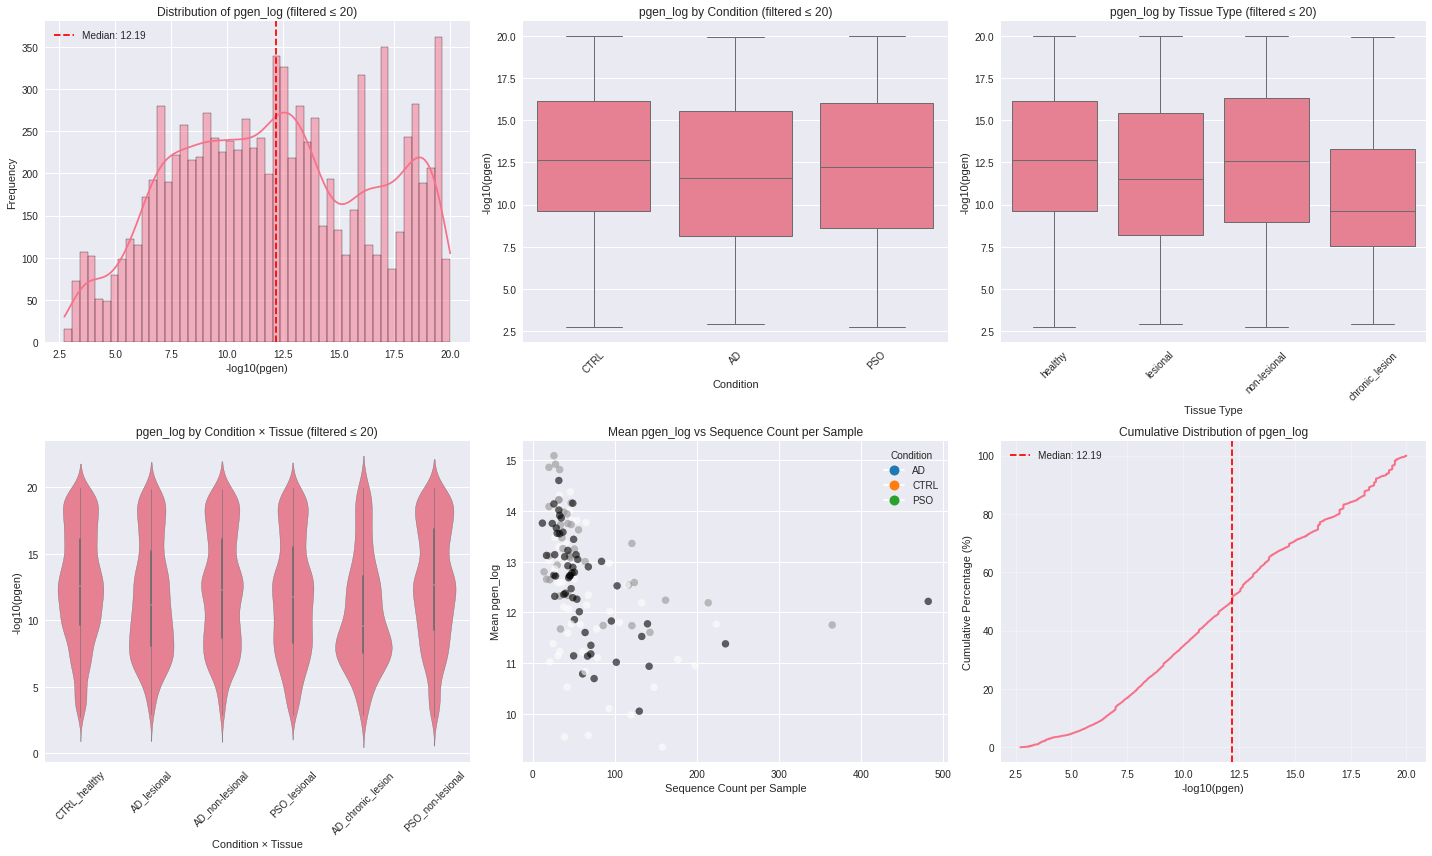


4. Patient-level comparisons...
Found 34 patients with tissue types for comparison


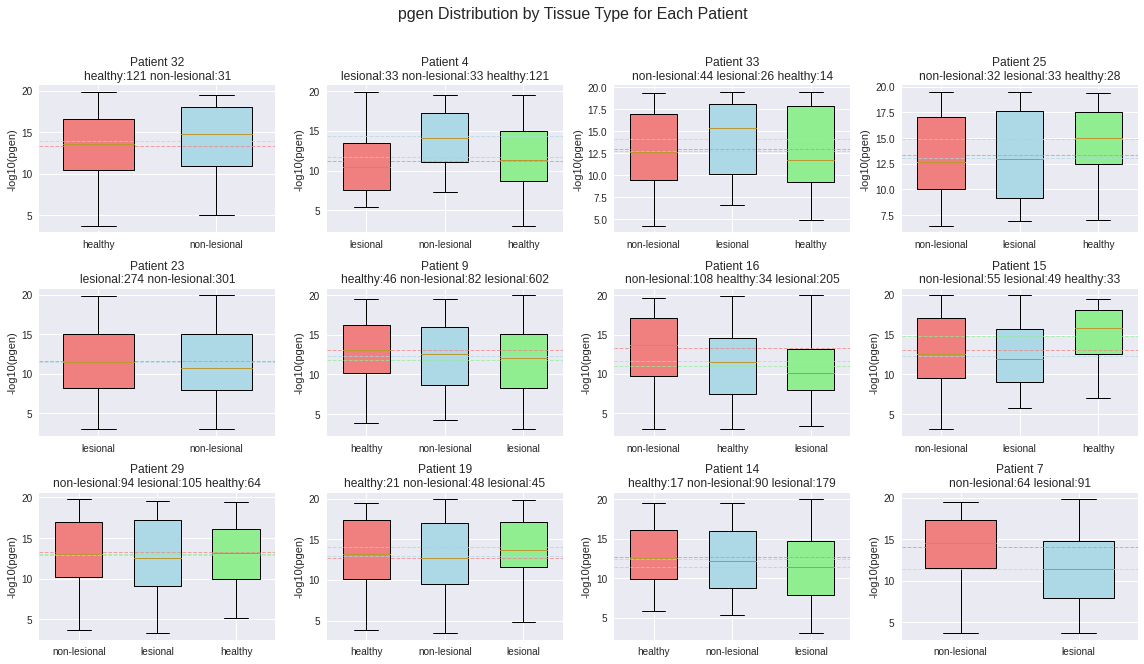


5. V gene comparisons by patient (family level)...


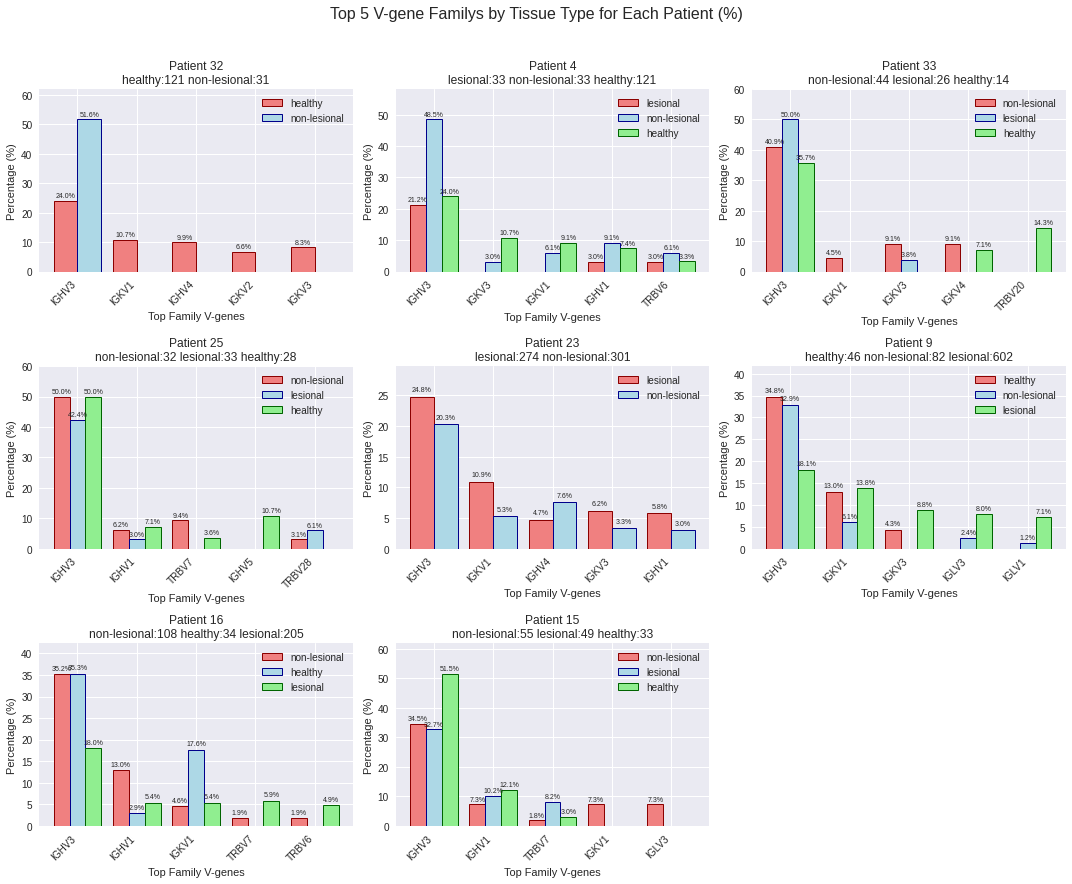


6. V gene comparisons by patient (gene level)...


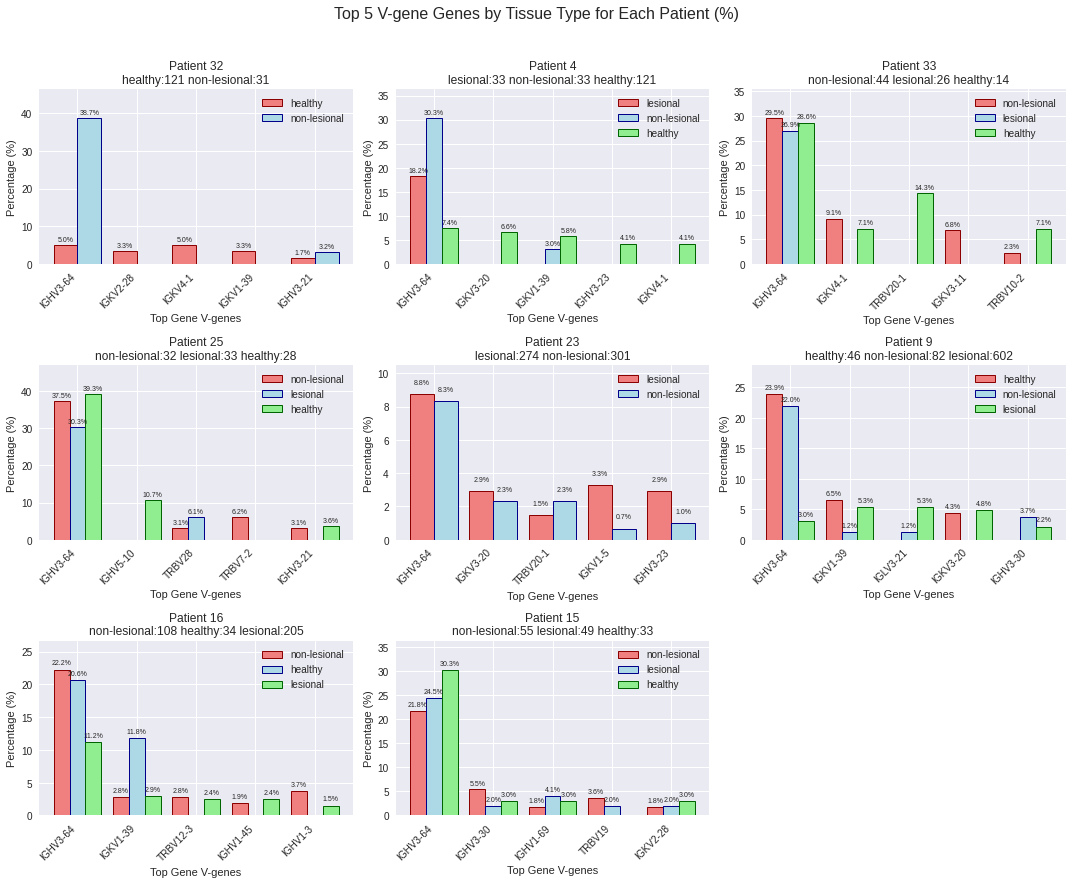


7. Creating comparison heatmaps for patients...


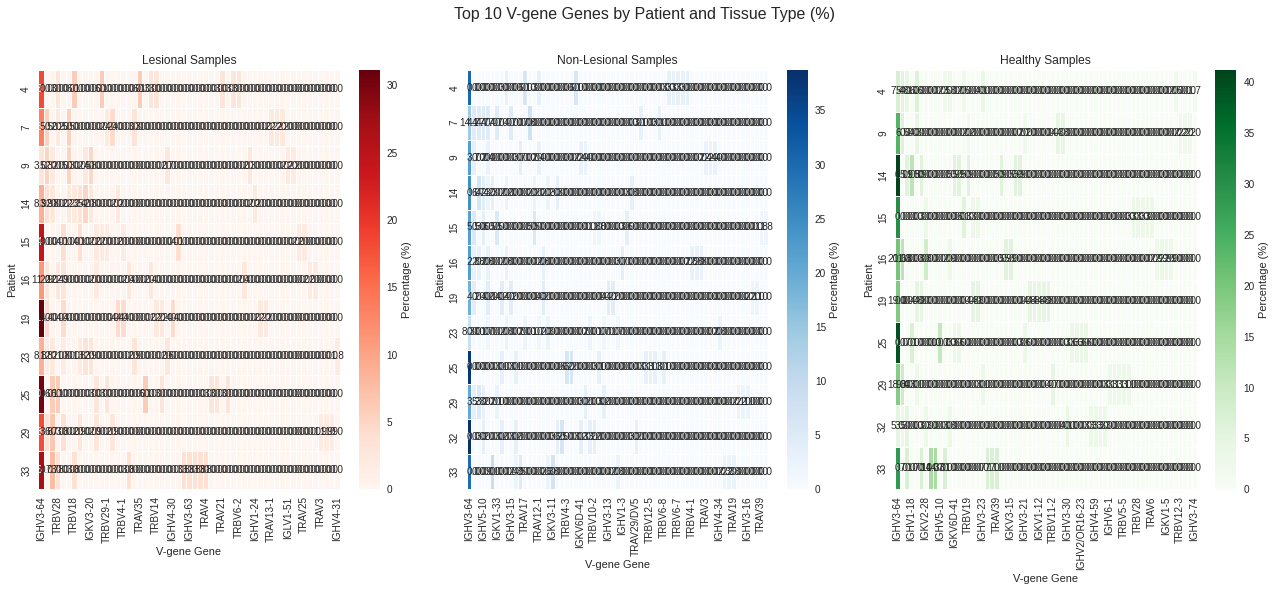


Patient-level visualization pipeline completed!


In [5]:
main_visualization_pipeline(df=df, group_by='patient')

Data shape: (16172, 125)
Grouping by: condition
Columns: ['duplicate_count', 'sequence_id', 'sequence', 'sequence_aa', 'locus', 'stop_codon', 'vj_in_frame', 'v_frameshift', 'productive', 'rev_comp', 'complete_vdj', 'd_frame', 'v_call', 'd_call', 'j_call', 'c_call', 'sequence_alignment', 'germline_alignment', 'sequence_alignment_aa', 'germline_alignment_aa', 'v_alignment_start', 'v_alignment_end', 'd_alignment_start', 'd_alignment_end', 'j_alignment_start', 'j_alignment_end', 'c_alignment_start', 'c_alignment_end', 'v_sequence_alignment', 'v_sequence_alignment_aa', 'v_germline_alignment', 'v_germline_alignment_aa', 'd_sequence_alignment', 'd_sequence_alignment_aa', 'd_germline_alignment', 'd_germline_alignment_aa', 'j_sequence_alignment', 'j_sequence_alignment_aa', 'j_germline_alignment', 'j_germline_alignment_aa', 'c_sequence_alignment', 'c_sequence_alignment_aa', 'c_germline_alignment', 'c_germline_alignment_aa', 'fwr1', 'fwr1_aa', 'cdr1', 'cdr1_aa', 'fwr2', 'fwr2_aa', 'cdr2', 'cdr2_a

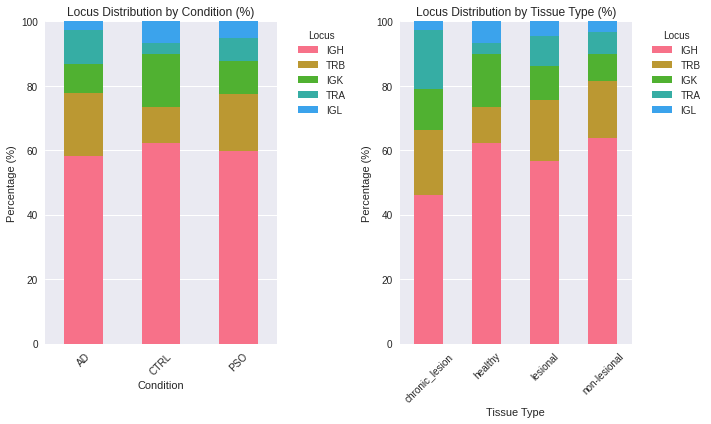


2. Plotting V gene frequencies (percentage)...


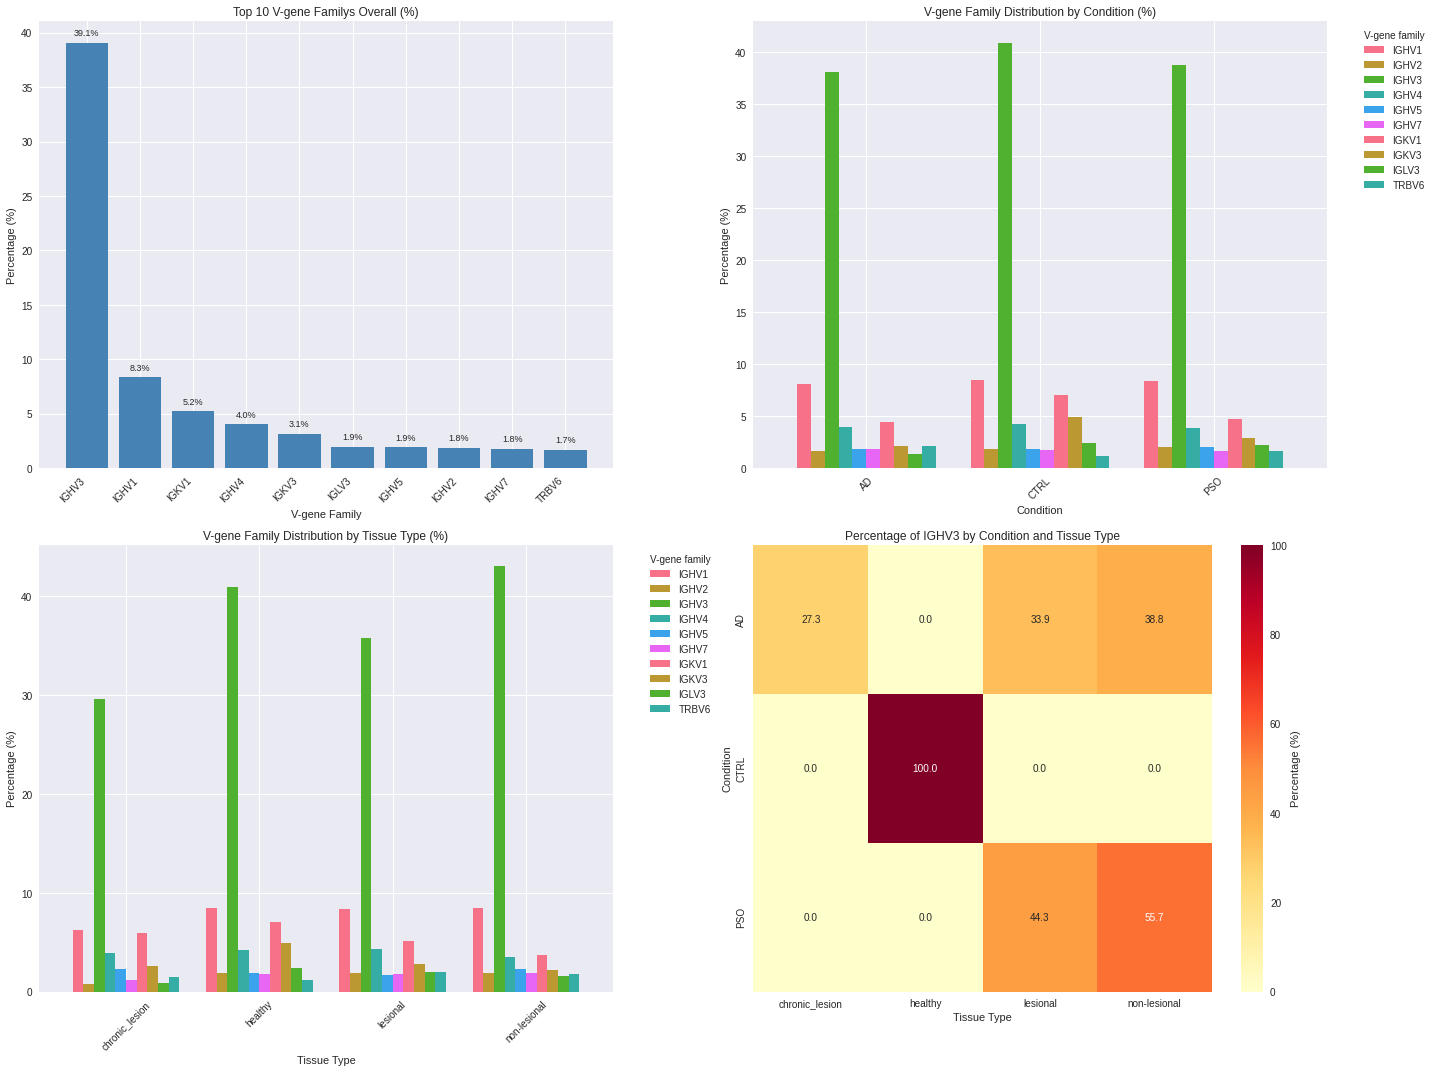

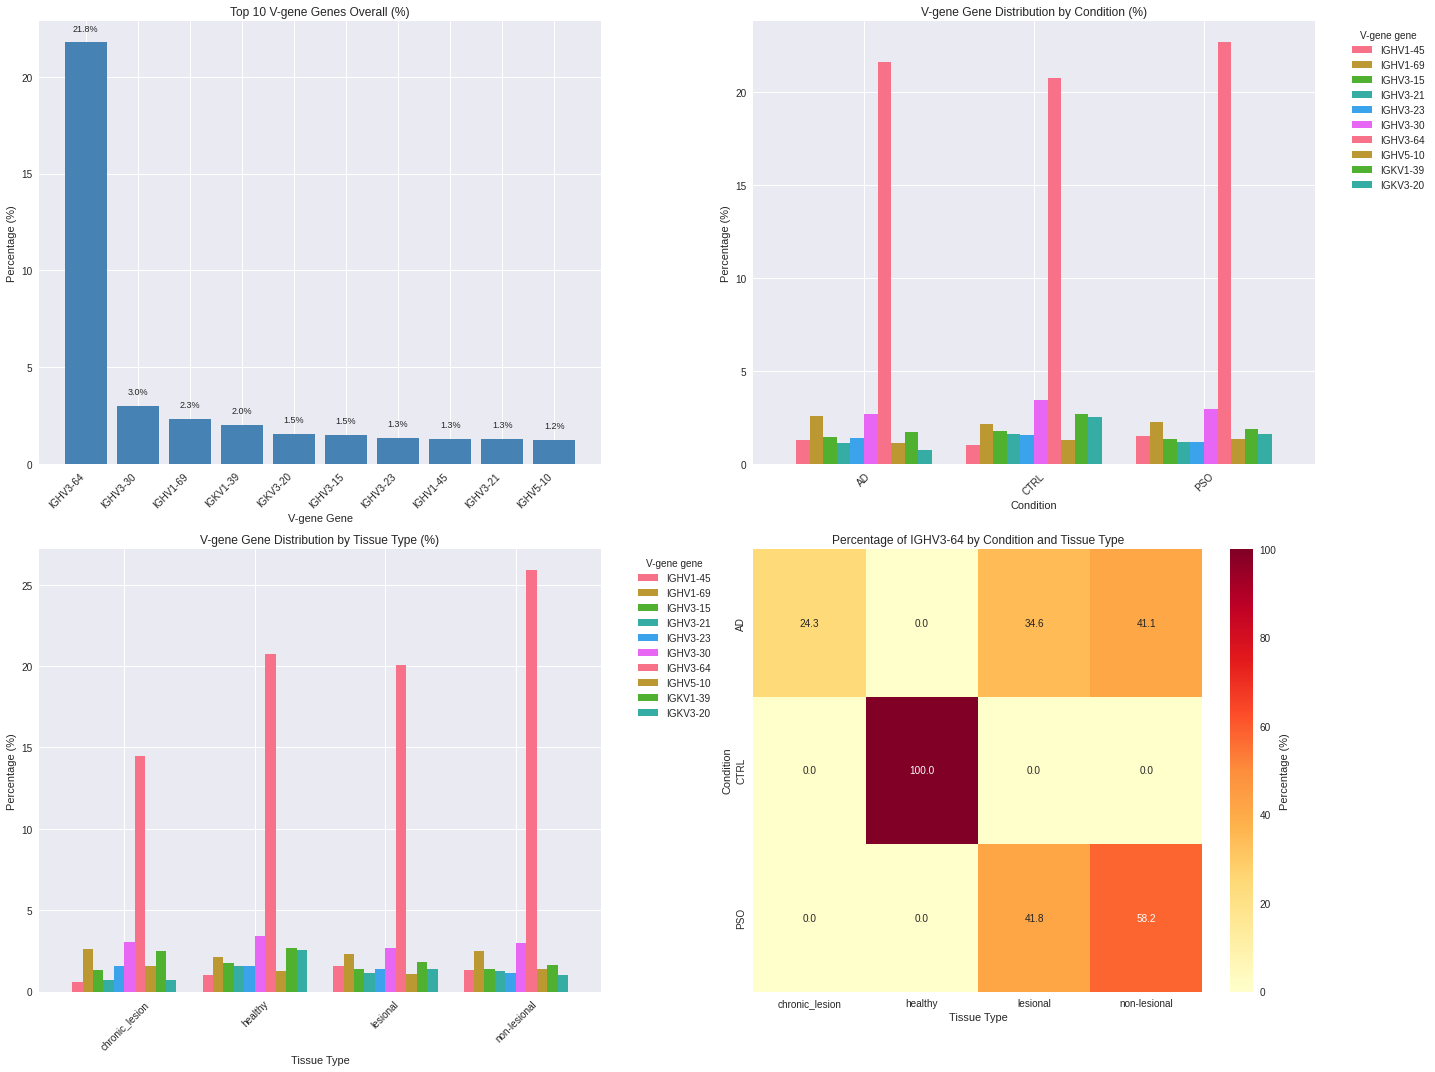


3. Plotting pgen distributions (with cutoff)...
Filtered out 6600 sequences with pgen_log > 20
Remaining sequences: 9572


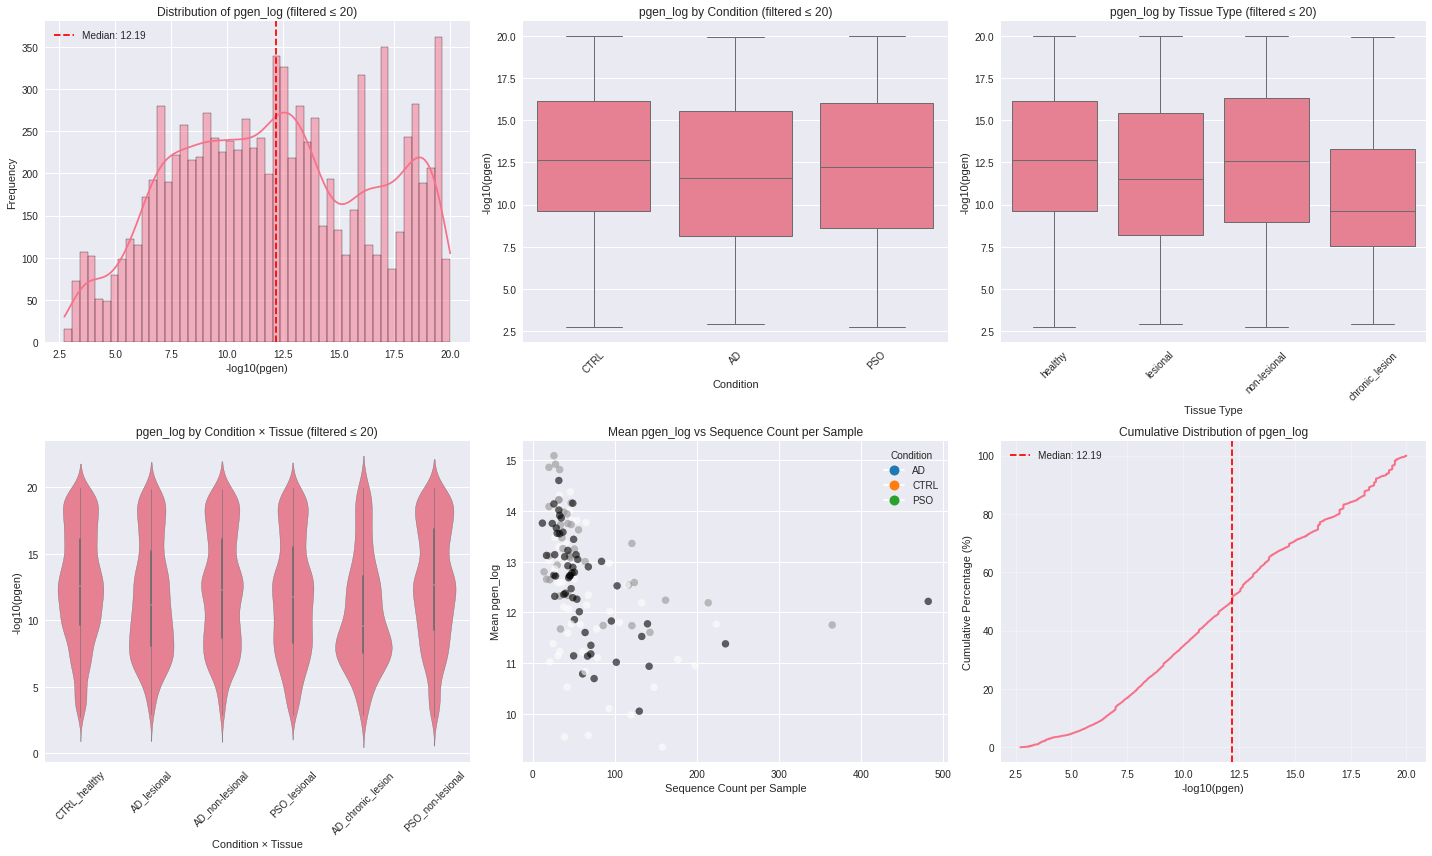


4. Condition-level comparisons...
Found 2 conditions with tissue types for comparison


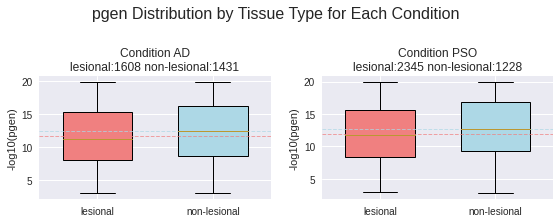


5. V gene comparisons by condition (family level)...


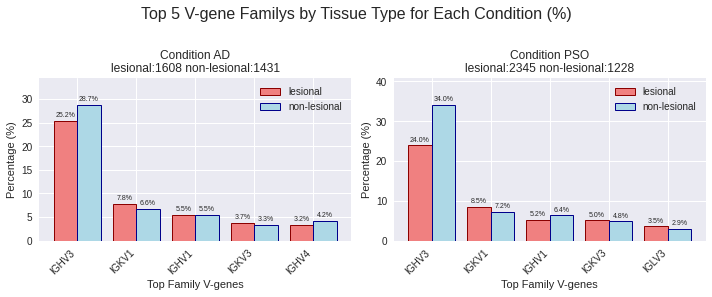


6. V gene comparisons by condition (gene level)...


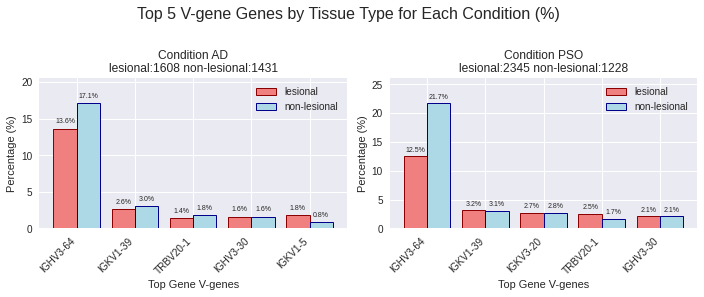


7. Creating comparison heatmaps for conditions...


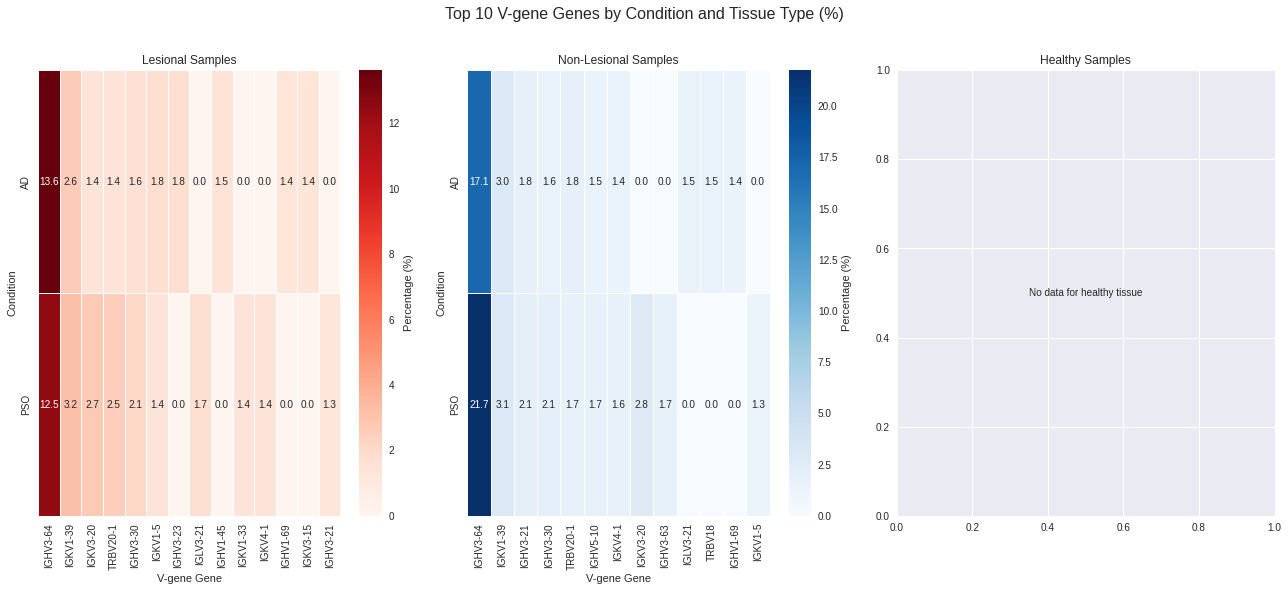


Condition-level visualization pipeline completed!


In [6]:
main_visualization_pipeline(df=df, group_by='condition')